## Install necesary packages

In [209]:
if False:
    %pip install pandas numpy matplotlib seaborn geopandas scikit-learn statsmodels openpyxl

In [210]:
notebook_analysis = True

# Read in data


In [211]:
import pandas as pd
import geopandas as gpd
import importlib
import warnings

# Import your custom analysis module
import analysis

# Reload ensures that if you edit analysis.py, the notebook picks up the changes
importlib.reload(analysis)
warnings.filterwarnings('ignore')

# 1. Define File Paths
excel_path = "./input_data/032026_C3PM_Analyst_Assignment_rev0A.xlsx"
shapefile_path = "./input_data/shape_files/SL_CGIS_SUB_CNCL_2011.shp"

# 2. Load the Data
df_financial = pd.read_excel(excel_path, sheet_name="financial_data")

df_procurement = pd.read_excel(excel_path, sheet_name="procurement_register")
df_attributes = pd.read_excel(excel_path, sheet_name="project_attributes")
gdf_subcouncils = gpd.read_file(shapefile_path)

print("--- Data Loading Complete ---\n")


--- Data Loading Complete ---



# Forecasting 

## CPI adjustment



--- Transition into FY2026 (Notice Actuals are now NaN for future periods) ---


,Financial Year,Period,Actual,Original Approved Budget
101,2025,11,7.516486e+08,5.997535e+08
102,2025,12,7.974950e+08,6.764824e+08
103,2025,13,1.876201e+08,0.000000e+00
104,2026,1,5.498828e+08,1.022930e+09
105,2026,2,5.713137e+08,9.793709e+08
106,2026,3,6.378821e+08,1.113981e+09
107,2026,4,NaN,1.084196e+09
108,2026,5,NaN,8.612643e+08
109,2026,6,NaN,8.675621e+08
110,2026,7,NaN,8.817793e+08


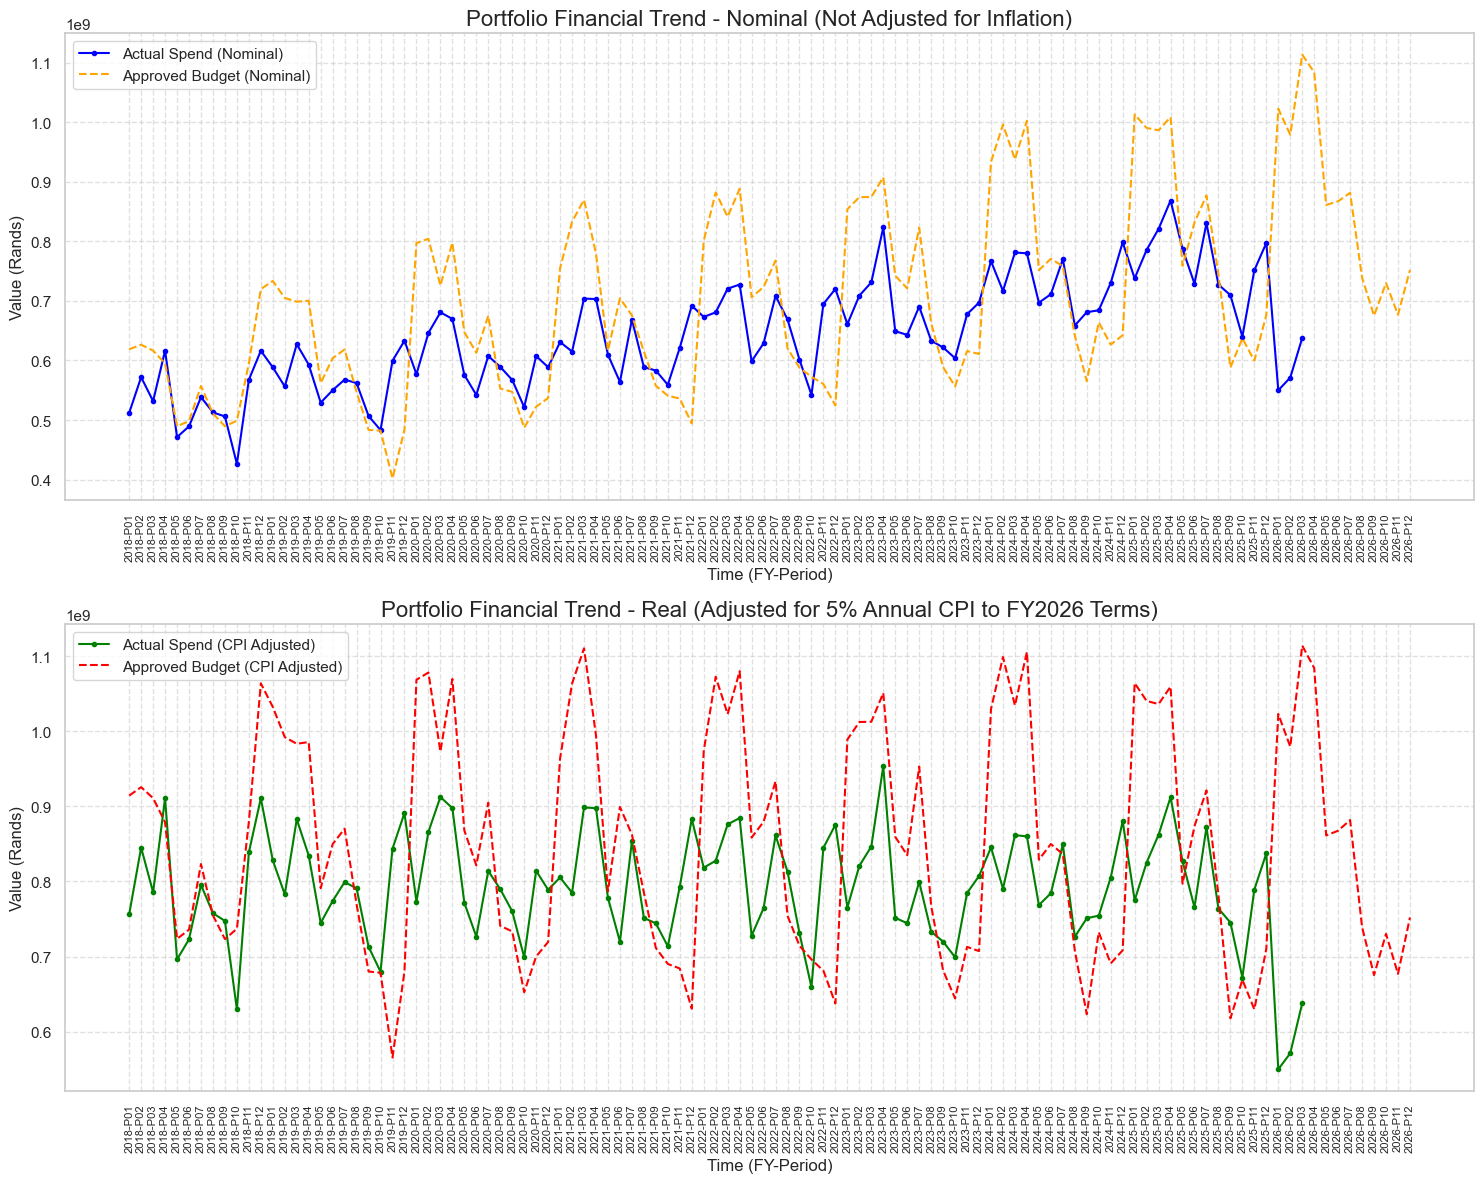

In [212]:
df_fin_pivot, portfolio_ts = analysis.plot_portfolio_financial_trends(df_financial)

## Forecast spending for FY26


--- Model Validation Results (Predicting FY25) ---
1. SARIMA MAPE:          4.57%
2. Holt-Winters MAPE:    3.49%
3. Ensemble MAPE:        3.51%
>>> Auto-Selected Best Model: Holt-Winters (MAPE: 3.49%)



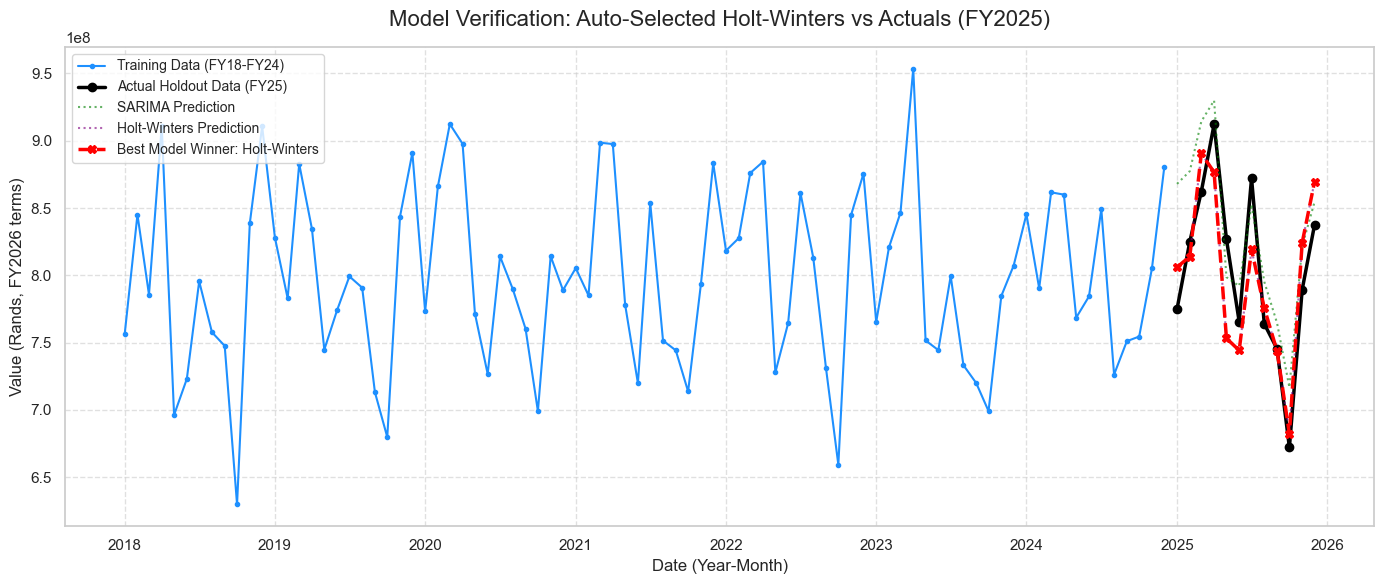

--- FY2026 Forecast Summary (Auto-Selected Model) ---
Total Approved Budget: R 10,384,808,726.41
Actual Spend So Far (P1-P3): R 1,759,078,635.50
Forecasted Spend (P4-P12): R 5,139,258,313.67
Expected EOY Spend: R 6,898,336,949.17
Variance (Target vs. Expected): R 3,486,471,777.23
Is Portfolio on track? No, severely underperforming



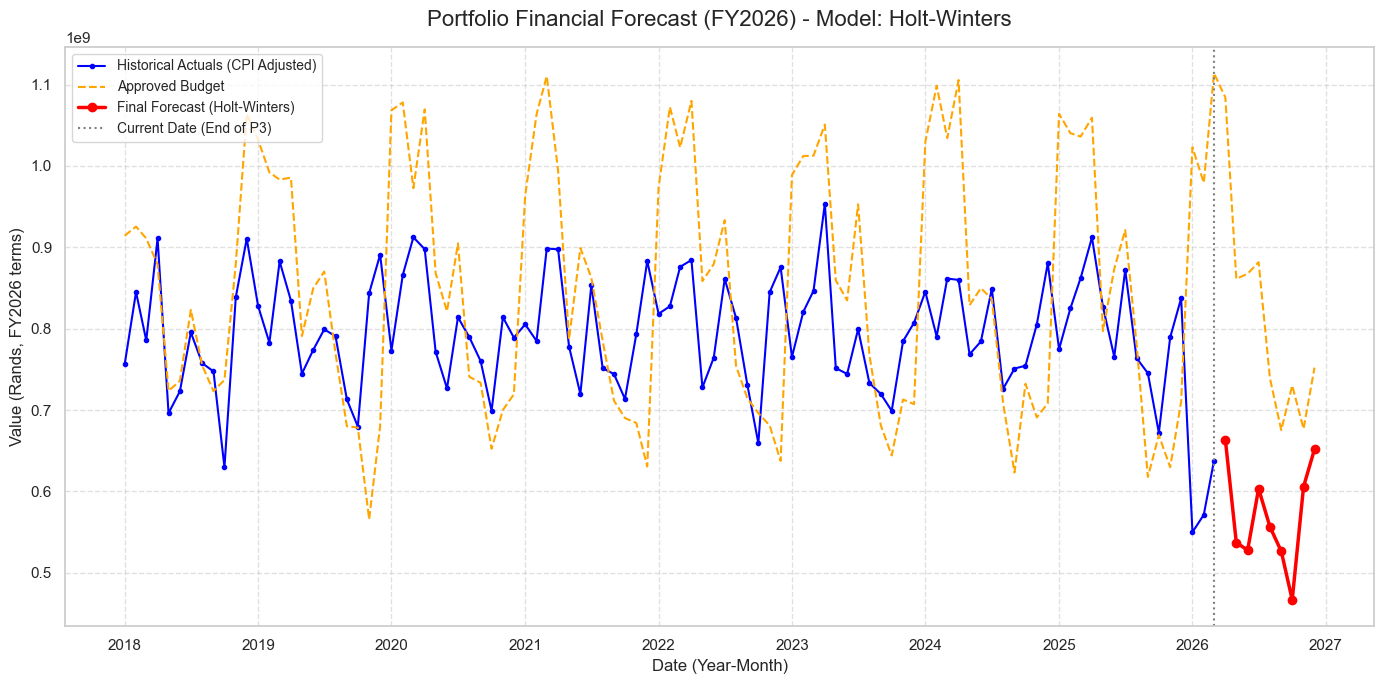

In [213]:
ts_data, final_forecast, forecast_dates, best_model_name = analysis.run_portfolio_forecast(portfolio_ts)


## Future forecasted over/underspending 

--- FY2026 Variance Forecast Summary (Derived from Auto-Selected Model) ---
Variance So Far (P1-P3): R -1,357,203,930.23
Forecasted Variance (P4-P12): R -2,129,267,847.00
Expected EOY Total Variance: R -3,486,471,777.23

Conclusion: The portfolio is consistently underspending and is projected to end the year massively below budget.


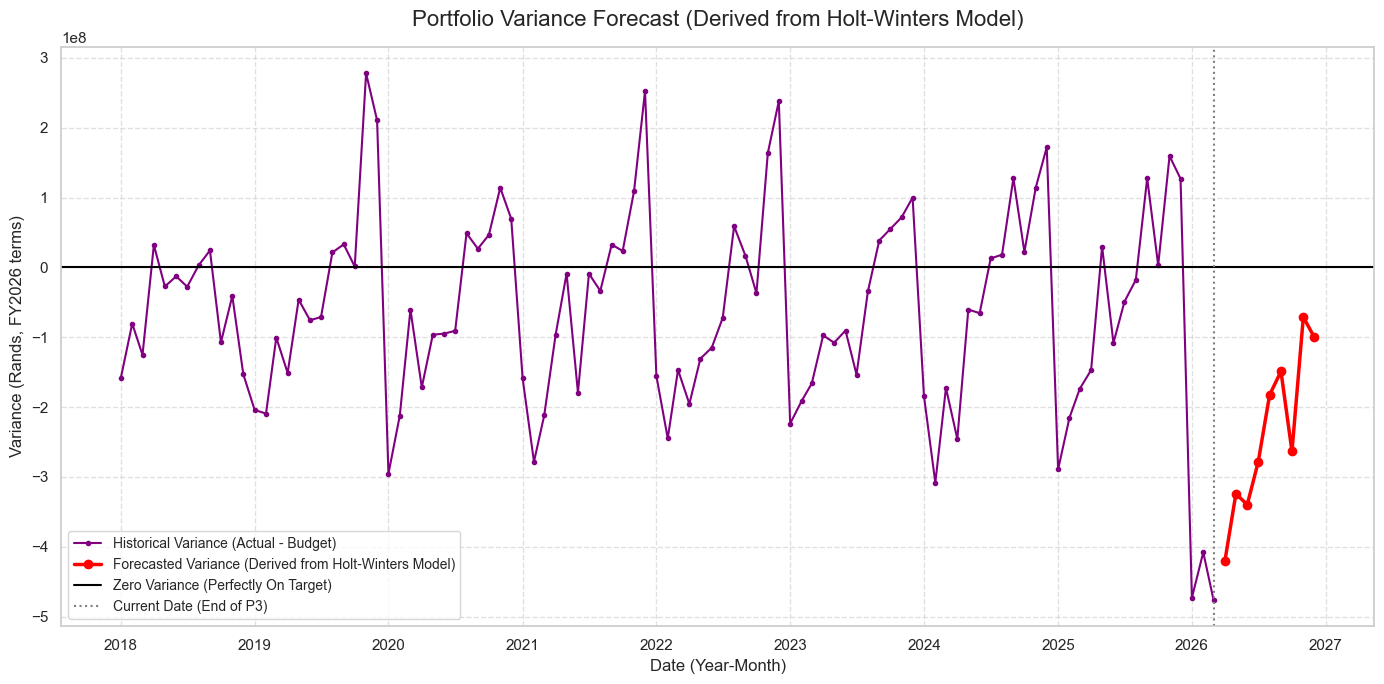

In [214]:
# --- Portfolio Macro Trends ---
analysis.plot_variance_forecast(ts_data, final_forecast, forecast_dates, best_model_name)

# Spatial risk

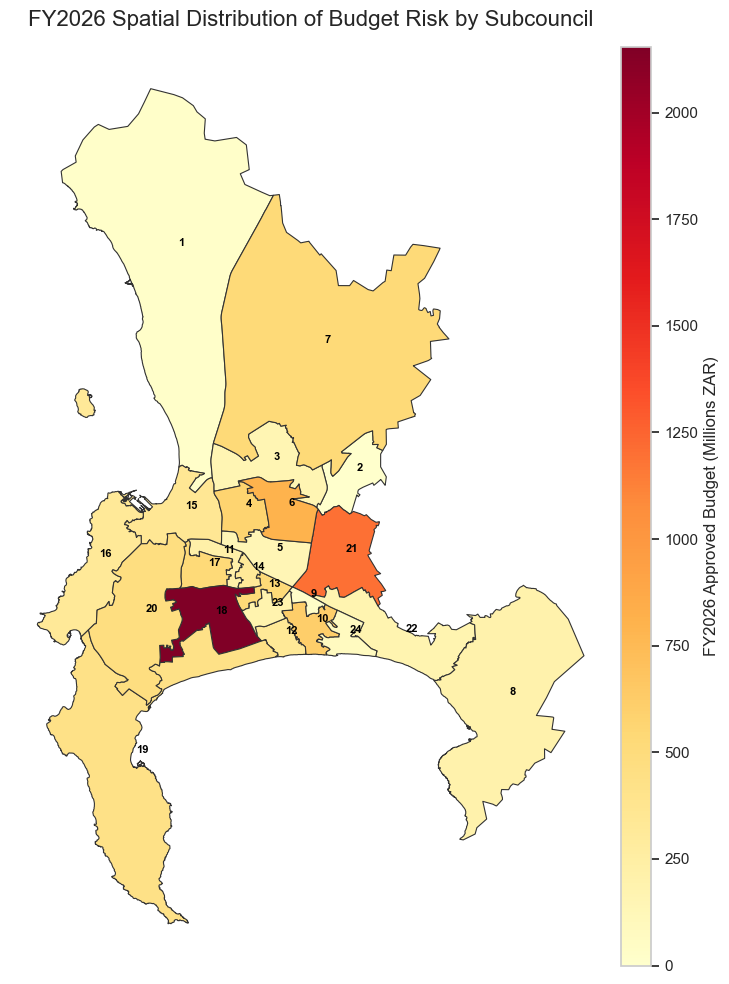

--- Top 3 Subcouncils by FY2026 Budget ---
Subcouncil 18: R 2,154,215,409.15
Subcouncil 21: R 1,199,379,741.17
Subcouncil 6: R 803,411,539.91


In [215]:
if notebook_analysis:
    analysis.plot_spatial_risk(df_financial, df_attributes, gdf_subcouncils)


# Stage bottlenecks

In [216]:
df_proj = analysis.analyze_structural_risk(df_financial, df_procurement, df_attributes)


--- Structural Risk & Procurement Bottlenecks ---
Total Remaining FY26 Budget (P4-P12): R 7,268,526,160.68
Total Budget 'Blocked' by Procurement Rules: R 3,456,386,076.00
Percentage of Budget Structurally at Risk: 47.55%

--- Breakdown of Blocked Budget by Reason ---
- Missing Contractor (Purchase): R 3,229,376,632.45
- Missing Service Provider: R 123,662,032.22
- Missing Contractor (Execution/Commission): R 103,347,411.32

--- PM Capacity Constraints ---
Found 0 Project Managers handling a disproportionately high number of active projects (>4 projects each).
This presents a significant delivery risk even if procurement is resolved.


# Number of projects per manager

In [217]:
if notebook_analysis:
    analysis.analyze_pm_capacity_concurrent(df_financial, df_attributes)


   PROJECT MANAGER CAPACITY ANALYSIS

YES. Out of 46 total Project Managers, 30 of them work on multiple projects concurrently in a single period.
There are 1934 specific historical and future months where this overlap occurs.

--- Top 10 Busiest PM Periods (Most Concurrent Projects) ---


,Project Manager,Financial Year,Period,Concurrent_Projects
0,PM 4,2023,6,4
1,PM 5,2020,10,4
2,PM 5,2019,7,4
3,PM 5,2019,8,4
4,PM 5,2019,9,4
5,PM 5,2019,10,4
6,PM 5,2019,11,4
7,PM 5,2019,12,4
8,PM 5,2020,5,4
9,PM 5,2020,6,4



--- Maximum Concurrent Projects Managed at Once (Top 10 PMs) ---


,Project Manager,Concurrent_Projects
0,PM 1,4
1,PM 10,4
2,PM 8,4
3,PM 7,4
4,PM 6,4
5,PM 5,4
6,PM 4,4
7,PM 9,4
8,PM 2,4
9,PM 3,4


Block_Reason
Concluded                                    480
On Track                                      61
Missing Contractor (Purchase)                 20
Missing Service Provider                       6
Missing Contractor (Execution/Commission)      1
Name: count, dtype: int64


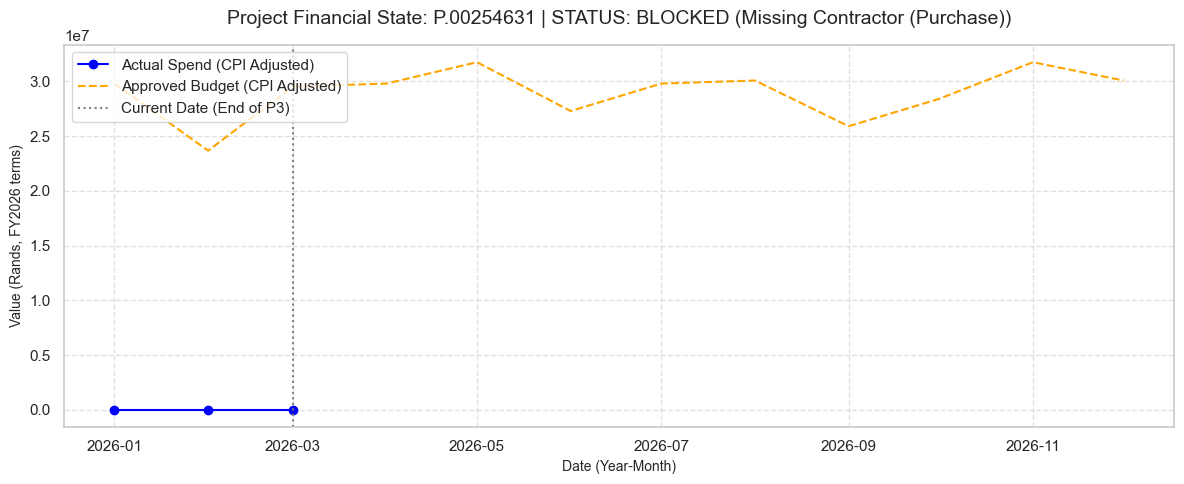

In [218]:
# --- Drill Downs ---
# Find the biggest blocked project to use as an example, otherwise fallback to the first project
if notebook_analysis:
    print(df_proj['Block_Reason'].value_counts())
    if 'Is_Blocked' in df_proj.columns and not df_proj[df_proj['Is_Blocked']].empty:
        example_project = df_proj[df_proj['Is_Blocked']].sort_values(by='Remaining_FY26_Budget', ascending=False).iloc[0]['Project Item Identifier']
    else:
        example_project = df_fin_pivot['Project Item Identifier'].iloc[0]

    analysis.plot_project_financials(example_project, df_fin_pivot, df_proj)

# Portfolio analysis

## Project manager spending analysis 

   PORTFOLIO ANALYSIS FOR: PM 1

--- PROJECT LIFECYCLE SUMMARY ---
Total Projects Assigned: 36
Active Projects: 4
Concluded Projects: 32

--- FY2026 BUDGET RISK ---
Total Remaining FY26 Budget (P4-P12): R 252,854,694.43
Budget Structurally Blocked: R 225,560,038.98
Percentage of PM's Budget at Risk: 89.21%

--- BLOCK REASONS ---
- Missing Contractor (Purchase): R 225,560,038.98 (2 projects)


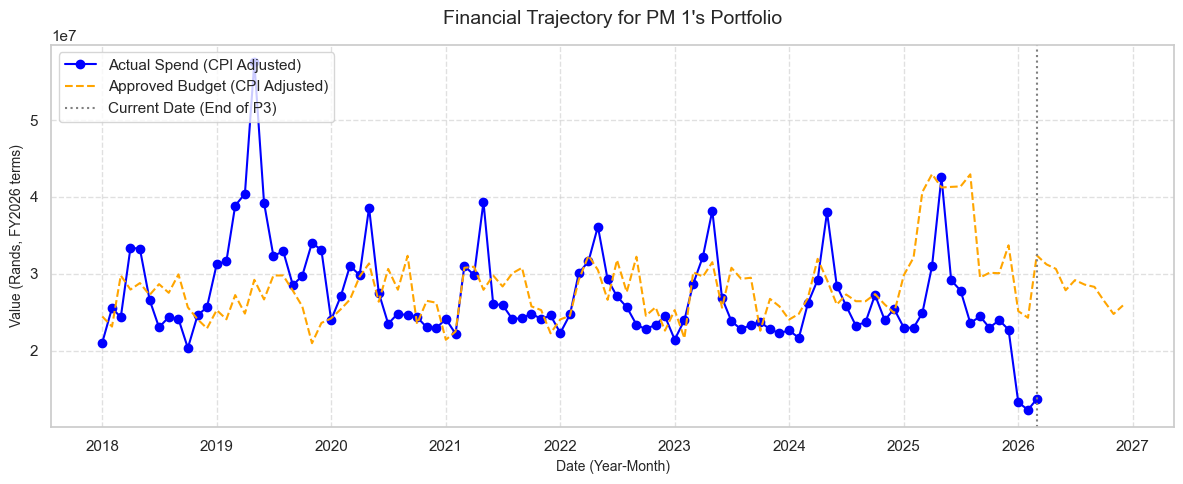

In [219]:
if notebook_analysis:
    analysis.analyze_pm_portfolio("PM 1", df_proj, df_fin_pivot)


## Project manager historical spending analysis

In [220]:
# analysis.analyze_pm_projects_individual("PM 1", df_proj, df_procurement, df_fin_pivot)


## Project managers spending breakdown

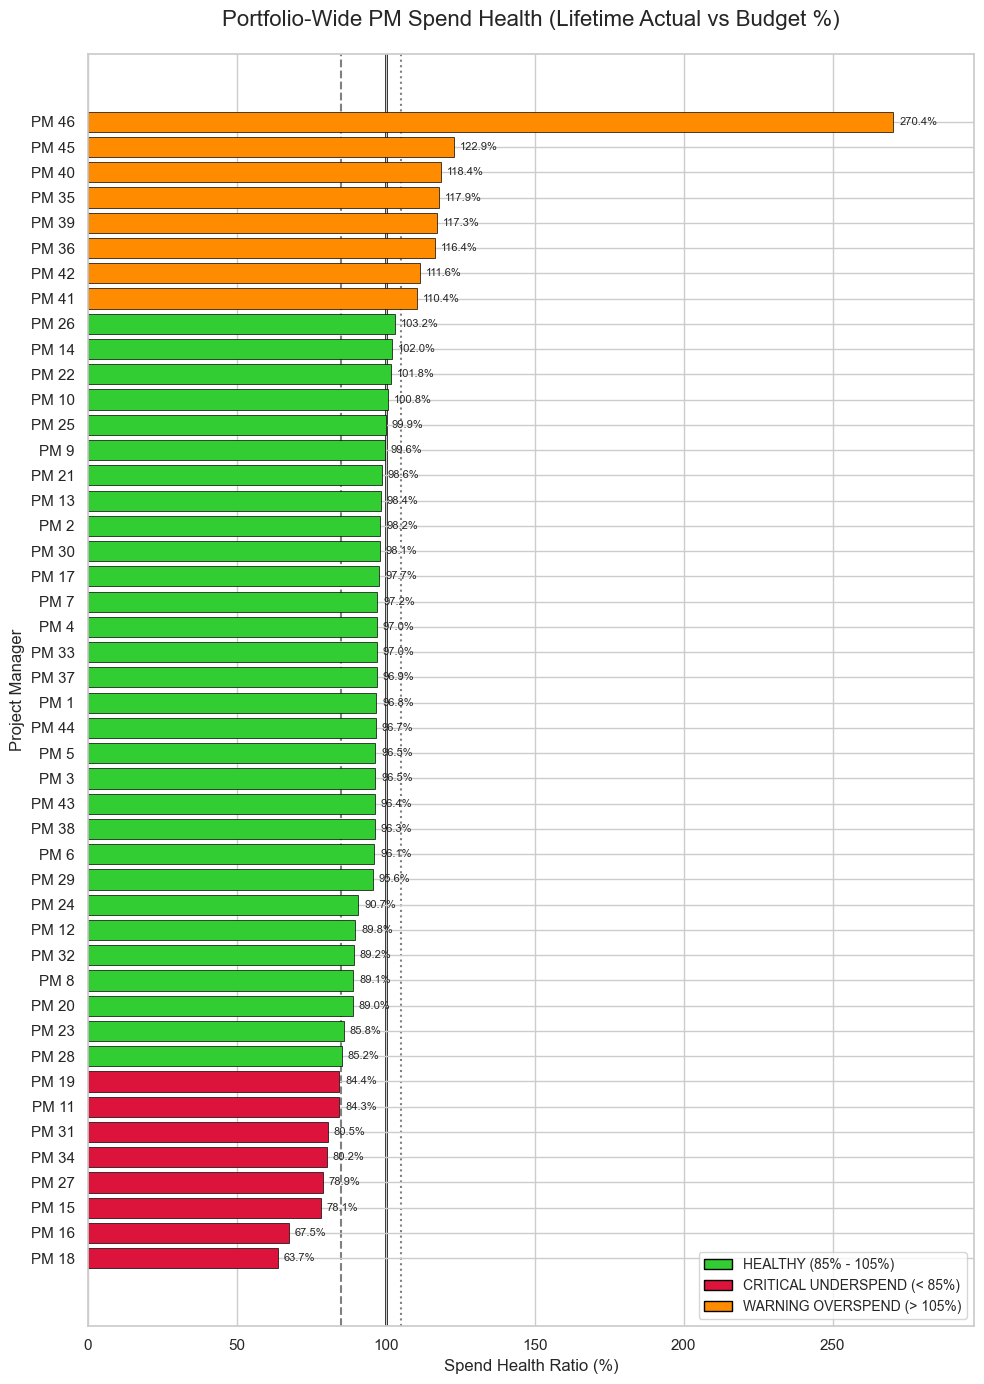

In [221]:
analysis.generate_pm_health_leaderboard(df_proj, df_fin_pivot)


## Specific project manager spend analysis

### Under spender - PM 18

   SPEND HEALTH SCORECARD: PM 18

Total Lifetime Budget Managed (Adjusted): R 533,214,392.70
Total Lifetime Actual Spend (Adjusted):   R 339,832,767.09
Lifetime Variance:                        R -193,381,625.61
Spend Health Ratio:                       63.7%
Status:                                   CRITICAL: Chronic Underspending



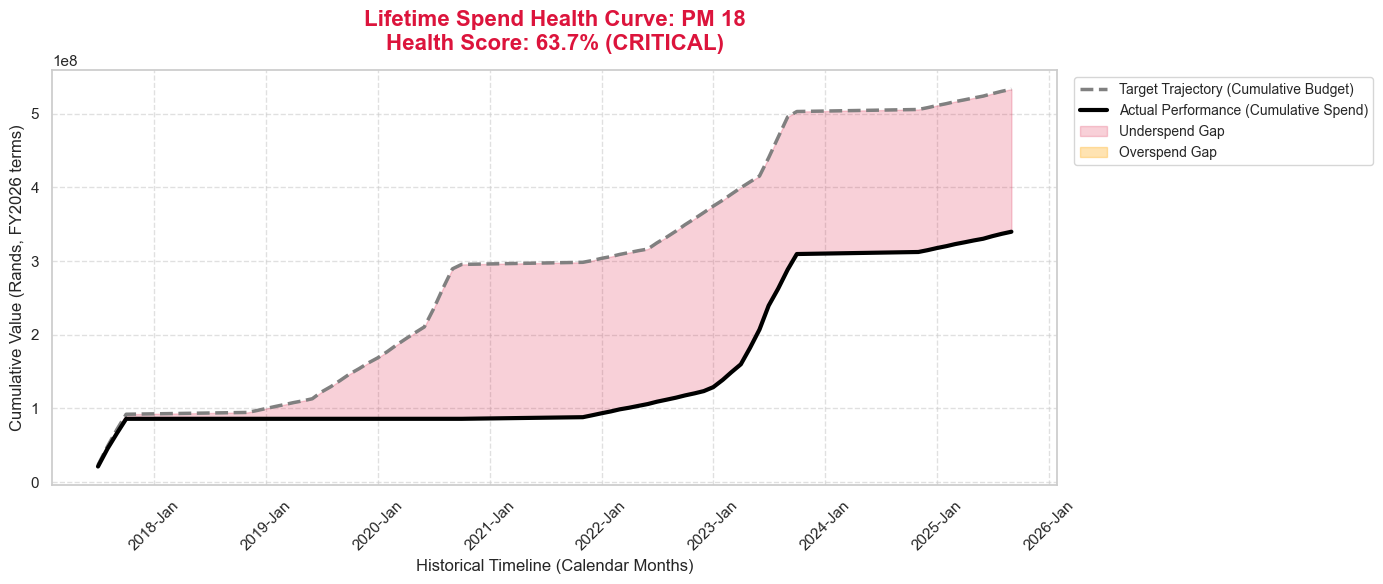

In [222]:
analysis.analyze_pm_spend_health_drilldown("PM 18", df_proj, df_fin_pivot)

### Over spender - PM 46

   SPEND HEALTH SCORECARD: PM 46

Total Lifetime Budget Managed (Adjusted): R 519,926,987.87
Total Lifetime Actual Spend (Adjusted):   R 1,406,119,580.12
Lifetime Variance:                        R 886,192,592.24
Spend Health Ratio:                       270.4%
Status:                                   WARNING: Chronic Overspending



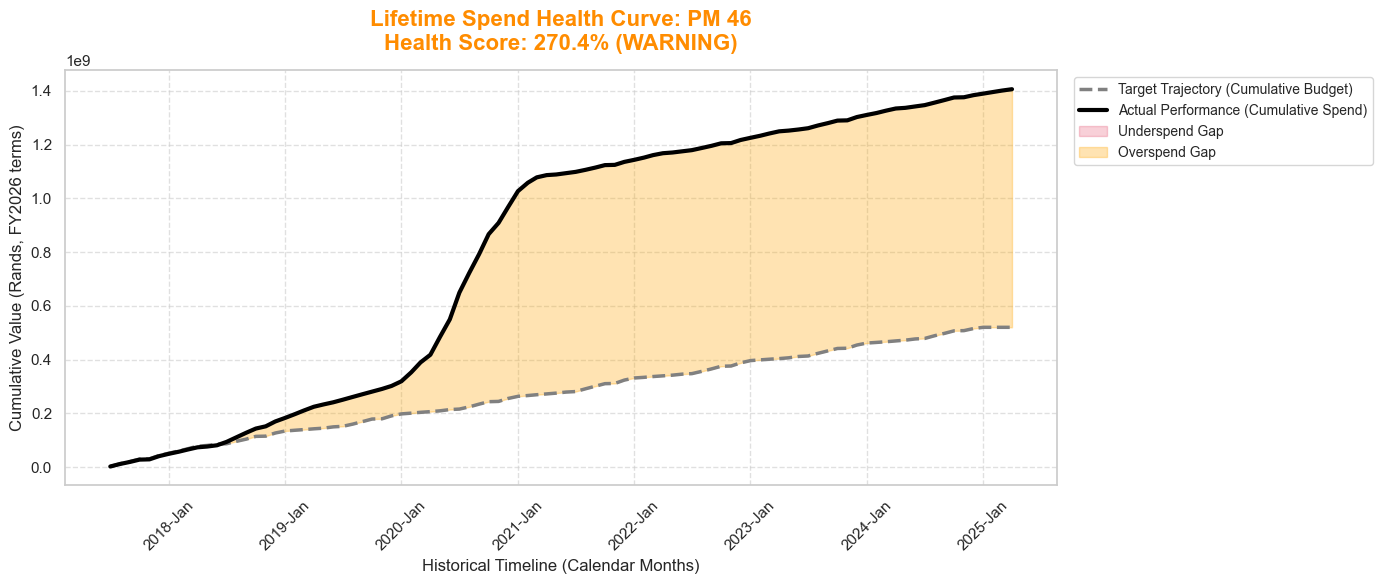

In [223]:
analysis.analyze_pm_spend_health_drilldown("PM 46", df_proj, df_fin_pivot)


### Healthy spender - PM 46

   SPEND HEALTH SCORECARD: PM 25

Total Lifetime Budget Managed (Adjusted): R 665,516,909.74
Total Lifetime Actual Spend (Adjusted):   R 665,071,348.22
Lifetime Variance:                        R -445,561.51
Spend Health Ratio:                       99.9%
Status:                                   HEALTHY: On Target



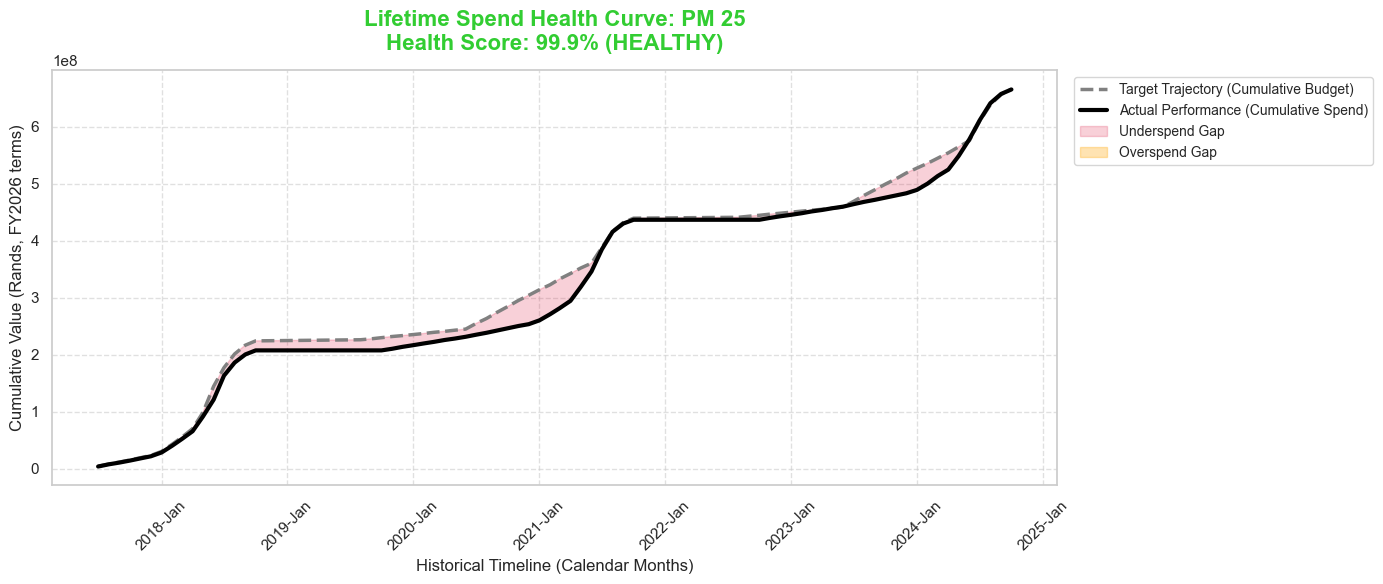

In [224]:
analysis.analyze_pm_spend_health_drilldown("PM 25", df_proj, df_fin_pivot)


## Under spending reason identification

   FORENSIC UNDERSPEND DIAGNOSTIC: PM 18

1. IDLE MONTHS: This PM spent R0 in 38.1% of their budgeted months.
2. EXECUTION EFFICIENCY: When they do spend money, they only hit 100.5% of their monthly target.
3. UPCOMING RISK: R 103.3 Million of their remaining FY26 budget is currently frozen due to missing contracts.



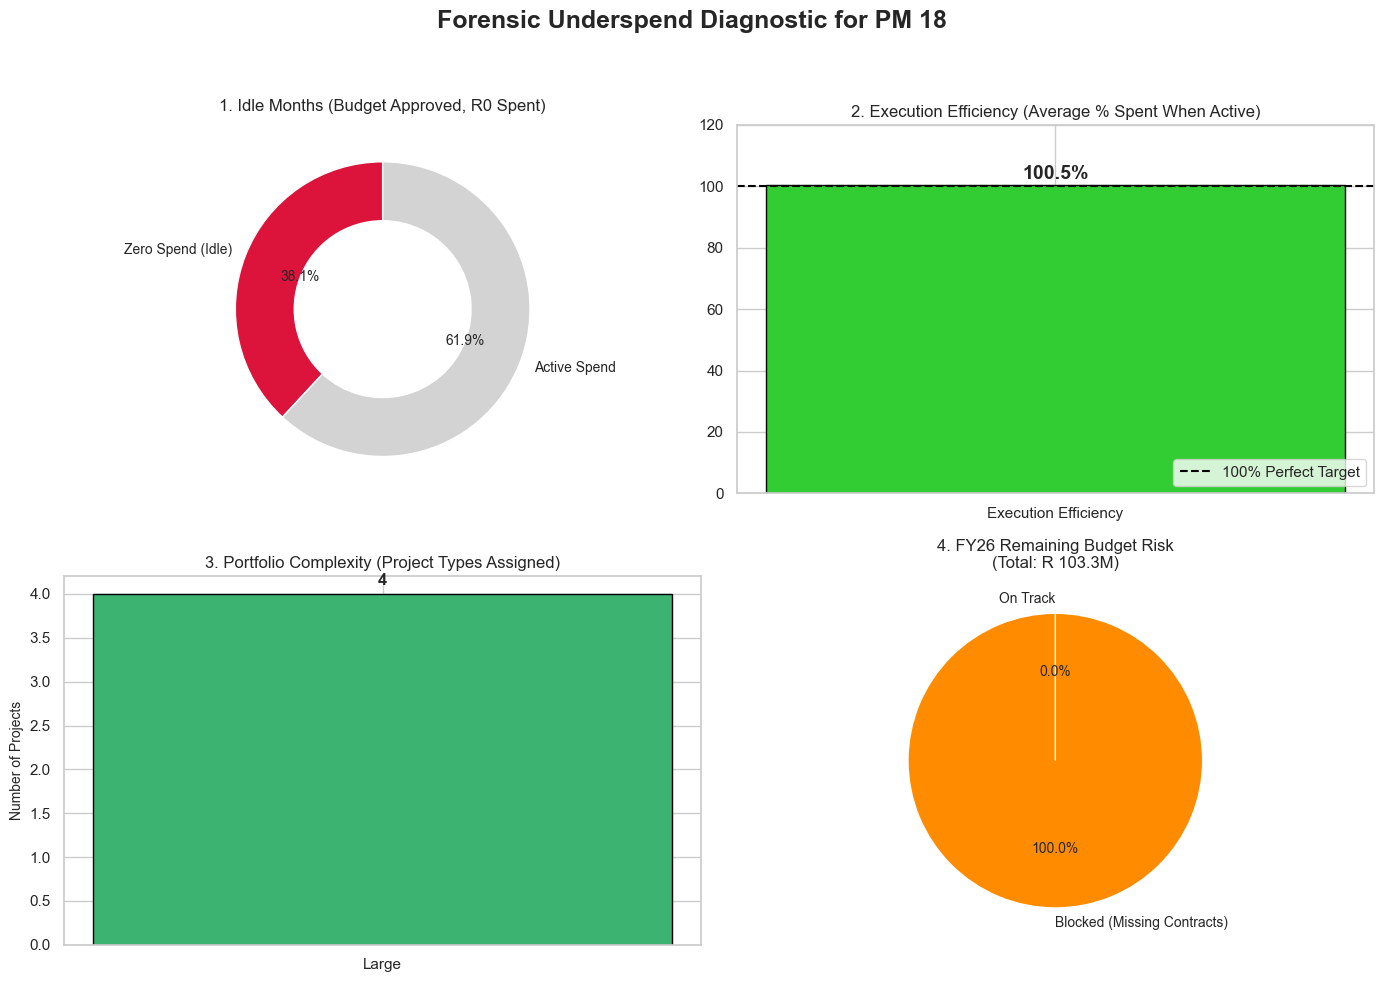

In [225]:
if notebook_analysis:
    analysis.diagnose_underspender("PM 18", df_attributes, df_financial, df_procurement, df_fin_pivot)


# Possible causes for underspending at current time

   Q2: ROOT CAUSE ANALYSIS BY PROJECT TYPE (FY26 YTD)

Total YTD Underspend (P1-P3): R 1,569,160,261.66

--- Breakdown of Underspend by Root Cause ---
- Execution Inefficiency (Has Contracts): R 951,202,336.40 (60.6%)
- Blocked: No Contractor: R 444,987,470.64 (28.4%)
- Delayed in Design Phase: R 96,649,267.91 (6.2%)
- Delayed in Design Phase (In-House): R 76,321,186.70 (4.9%)


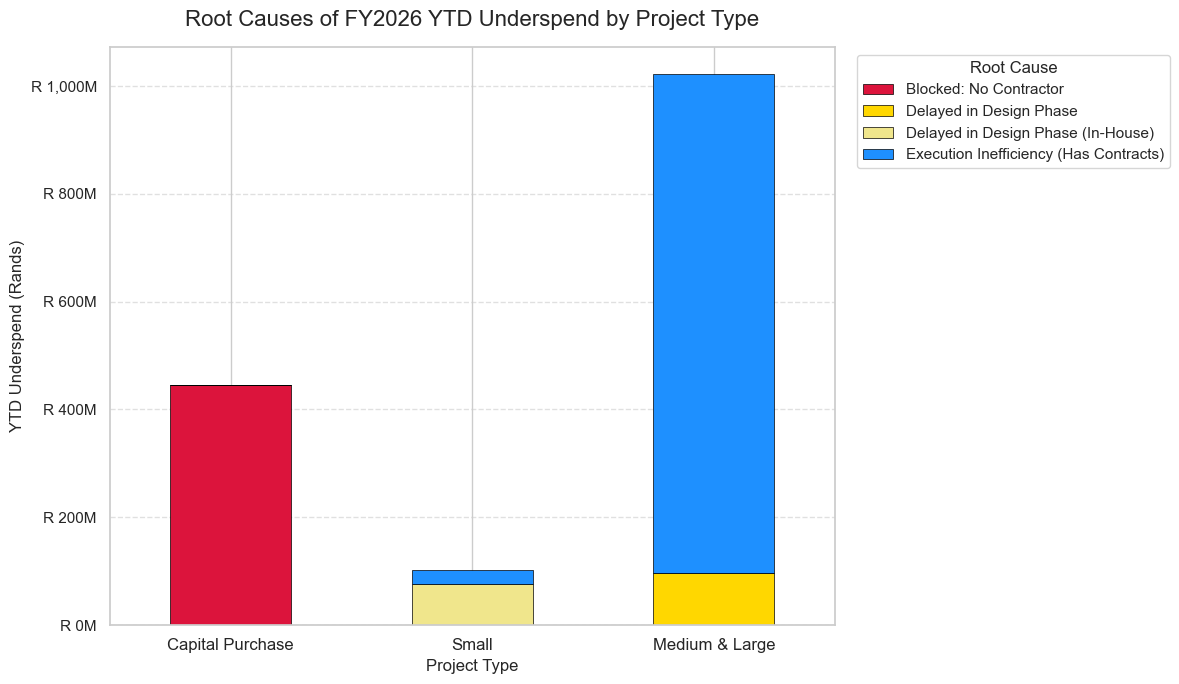

   Q2: ROOT CAUSE ANALYSIS BY LIFECYCLE STAGE (FY26 YTD)

Total YTD Underspend (P1-P3): R 1,569,160,261.66

--- Breakdown of Underspend by Lifecycle Phase ---
- Execution Phase: Inefficiency (Contractor Active but Slow): R 760,353,050.42 (48.5%)
- Execution Phase: Blocked (Missing Contractor): R 444,987,470.64 (28.4%)
- Design Phase: Slow Spending / Delayed: R 172,970,454.61 (11.0%)
- Commissioning Phase: Handover Delays: R 164,564,435.00 (10.5%)
- Concluded Phase: Late Invoice/Retention Payments: R 26,284,850.98 (1.7%)


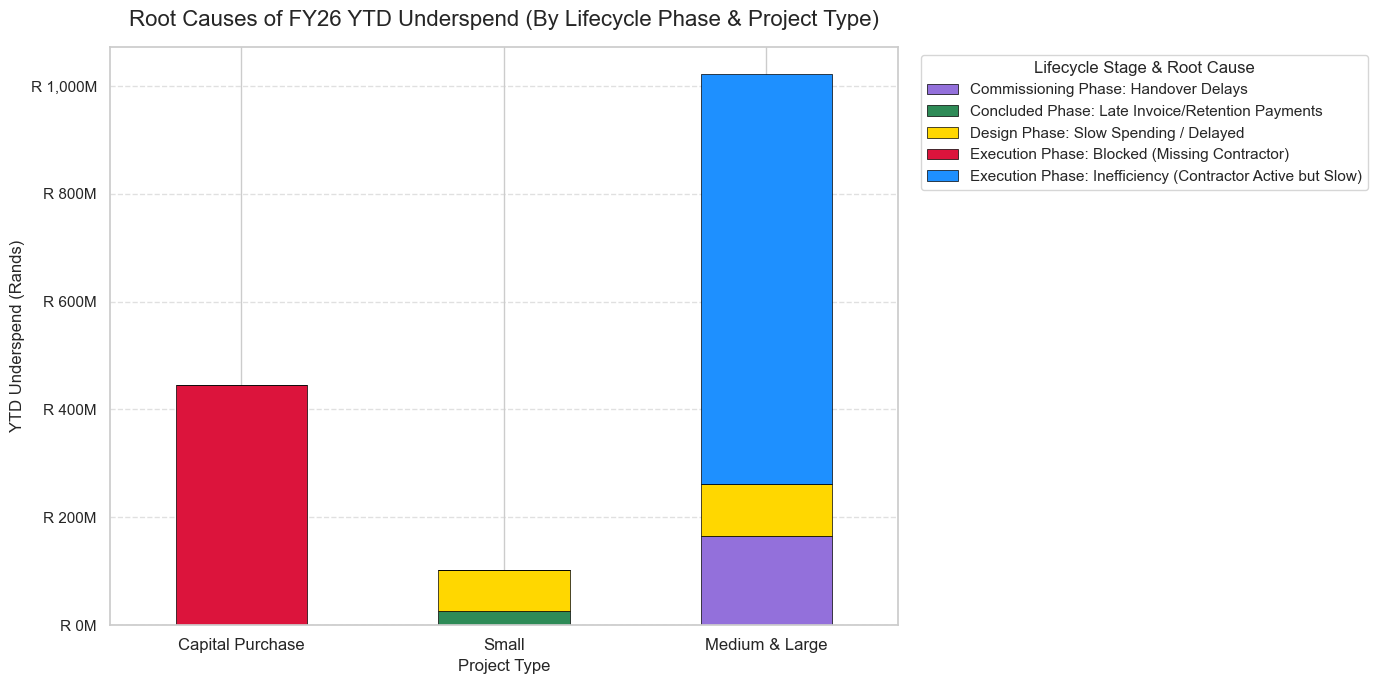

In [226]:
# --- Root Cause & Transition Analysis ---
analysis.analyze_root_causes_by_type(df_financial, df_attributes, df_procurement)
analysis.analyze_root_causes_by_lifecycle(df_financial, df_attributes, df_procurement)
 

In [227]:
# ==============================================================================
# CELL: Q2 ROOT CAUSE ANALYSIS BY PROJECT TYPE & WATCHLIST
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

def analyze_root_causes_by_type_standalone(df_financial, df_attributes, df_procurement):
    print("==================================================")
    print("   Q2: ROOT CAUSE ANALYSIS BY PROJECT TYPE (FY26 YTD)")
    print("==================================================\n")
    
    # 1. Calculate YTD Underspend
    fy26_ytd = df_financial[(df_financial['Financial Year'] == 2026) & (df_financial['Period'] <= 3)]
    ytd_pivot = fy26_ytd.pivot_table(index='Project Item Identifier', columns='Financial View', values='Value', aggfunc='sum').reset_index().fillna(0)
    ytd_pivot['YTD_Underspend'] = ytd_pivot['Original Approved Budget'] - ytd_pivot['Actual']
    
    # 2. Merge with Attributes (Including Project Manager for the Watchlist)
    df_merged = ytd_pivot[ytd_pivot['YTD_Underspend'] > 0].copy().merge(
        df_attributes[['Project Item Identifier', 'Type', 'Stage', 'Project Manager']], 
        on='Project Item Identifier', how='left'
    )
    
    # 3. Assess Active Contracts
    current_date = pd.to_datetime('2025-09-30')
    df_proc = df_procurement.copy()
    df_proc['Date of Expiry'] = pd.to_datetime(df_proc['Date of Expiry'])
    df_proc['Award Date'] = pd.to_datetime(df_proc['Award Date'])
    active_contracts = df_proc[(df_proc['Status'] == 'Awarded') & 
                               (df_proc['Award Date'] <= current_date) & 
                               (df_proc['Date of Expiry'] >= current_date)]
    
    proc_summary = active_contracts.groupby(['Project Item Identifier', 'Category']).size().unstack(fill_value=0)
    proc_summary.columns = [col.lower() for col in proc_summary.columns]
    if 'service' not in proc_summary.columns: proc_summary['service'] = 0
    if 'contractor' not in proc_summary.columns: proc_summary['contractor'] = 0
    proc_summary['has_contractor'], proc_summary['has_service'] = proc_summary['contractor'] > 0, proc_summary['service'] > 0
    proc_summary = proc_summary.reset_index()
    
    df_merged = df_merged.merge(proc_summary[['Project Item Identifier', 'has_contractor', 'has_service']], on='Project Item Identifier', how='left').fillna({'has_contractor': False, 'has_service': False})
    
    # 4. Root Cause Logic
    def get_root_cause(row):
        t, s, has_con, has_svc = str(row['Type']).lower(), str(row['Stage']).lower(), row['has_contractor'], row['has_service']
        if t == 'capital purchase': return "Blocked: No Contractor" if not has_con else "Execution Inefficiency (Has Contracts)"
        elif t in ['large', 'medium']:
            if not has_svc: return "Blocked: No PSP (Design/Oversight)"
            if s in ['execution', 'commissioning'] and not has_con: return "Blocked: No Contractor"
            return "Delayed in Design Phase" if s == 'design' else "Execution Inefficiency (Has Contracts)"
        elif t == 'small':
            if s in ['execution', 'commissioning'] and not has_con: return "Blocked: No Contractor"
            return "Delayed in Design Phase (In-House)" if s == 'design' else "Execution Inefficiency (Has Contracts)"
        return "Other"

    df_merged['Root_Cause'] = df_merged.apply(get_root_cause, axis=1)
    
    # 5. Group Medium and Large Together
    def group_type(t):
        t_lower = str(t).lower()
        if t_lower in ['medium', 'large']: return 'Medium & Large'
        return t_lower.title()
    
    df_merged['Type'] = df_merged['Type'].apply(group_type)
    
    # 6. Prepare Plot Data
    plot_data = df_merged.groupby(['Type', 'Root_Cause'])['YTD_Underspend'].sum().unstack(fill_value=0)
    expected_order = ['Capital Purchase', 'Small', 'Medium & Large']
    if not plot_data.empty: 
        plot_data = plot_data.loc[[x for x in expected_order if x in plot_data.index]]
    
    print(f"Total YTD Underspend (P1-P3): R {df_merged['YTD_Underspend'].sum():,.2f}\n")
    print("--- Breakdown of Underspend by Root Cause ---")
 
    
    return df_merged


# 1. Run the function and save the returned dataframe
df_root_cause_by_type = analyze_root_causes_by_type_standalone(df_financial, df_attributes, df_procurement)

# 2. Instantly build the Watchlist using the returned data
print("\n==================================================")
print("   EXECUTIVE ACTION: TOP 10 WATCHLIST")
print("==================================================\n")

watchlist = df_root_cause_by_type.sort_values(by='YTD_Underspend', ascending=False).head(10)
watchlist = watchlist[['Project Item Identifier', 'Type', 'Stage', 'Project Manager', 'Root_Cause', 'YTD_Underspend']]

# Format currency cleanly
watchlist['YTD_Underspend'] = watchlist['YTD_Underspend'].apply(lambda x: f"R {x / 1e6:,.1f} M")
watchlist.columns = ['Project ID', 'Type', 'Current Stage', 'PM', 'Root Cause Bottleneck', 'Lost YTD Spend']

display(watchlist.reset_index(drop=True))

   Q2: ROOT CAUSE ANALYSIS BY PROJECT TYPE (FY26 YTD)

Total YTD Underspend (P1-P3): R 1,569,160,261.66

--- Breakdown of Underspend by Root Cause ---

   EXECUTIVE ACTION: TOP 10 WATCHLIST



,Project ID,Type,Current Stage,PM,Root Cause Bottleneck,Lost YTD Spend
0,P.00256143,Medium & Large,execution,PM 31,Execution Inefficiency (Has Contracts),R 126.7 M
1,P.00561324,Medium & Large,execution,PM 27,Execution Inefficiency (Has Contracts),R 115.7 M
2,P.00246531,Medium & Large,execution,PM 32,Execution Inefficiency (Has Contracts),R 99.0 M
3,P.00135426,Medium & Large,execution,PM 28,Execution Inefficiency (Has Contracts),R 90.4 M
4,P.00461235,Medium & Large,execution,PM 27,Execution Inefficiency (Has Contracts),R 87.3 M
5,P.00254631,Capital Purchase,execution,PM 3,Blocked: No Contractor,R 83.0 M
6,P.00321564,Medium & Large,execution,PM 34,Execution Inefficiency (Has Contracts),R 82.9 M
7,P.00546231,Capital Purchase,execution,PM 4,Blocked: No Contractor,R 73.8 M
8,P.00632451,Capital Purchase,execution,PM 6,Blocked: No Contractor,R 69.2 M
9,P.00165432,Capital Purchase,execution,PM 5,Blocked: No Contractor,R 64.6 M


Total Portfolio YTD Underspend Analysed: R 1,569,160,261.66

► CAPITAL PURCHASES
  Total Underspend in Bucket: R 444,987,470.64
  Primary Root Cause: Procurement Bottleneck: Supplier Tender stuck 'In Process'
  Financial Impact: R 285,911,586.18 (64.3% of Capital Purchases underspend)

► SMALL PROJECTS
  Total Underspend in Bucket: R 102,606,037.68
  Primary Root Cause: Lifecycle Hangover: Delayed in internal/in-house Design phase
  Financial Impact: R 76,321,186.70 (74.4% of Small Projects underspend)

► MEDIUM & LARGE PROJECTS
  Total Underspend in Bucket: R 1,021,566,753.34
  Primary Root Cause: Execution Inefficiency: Slow construction despite all active contracts
  Financial Impact: R 924,917,485.43 (90.5% of Medium & Large Projects underspend)



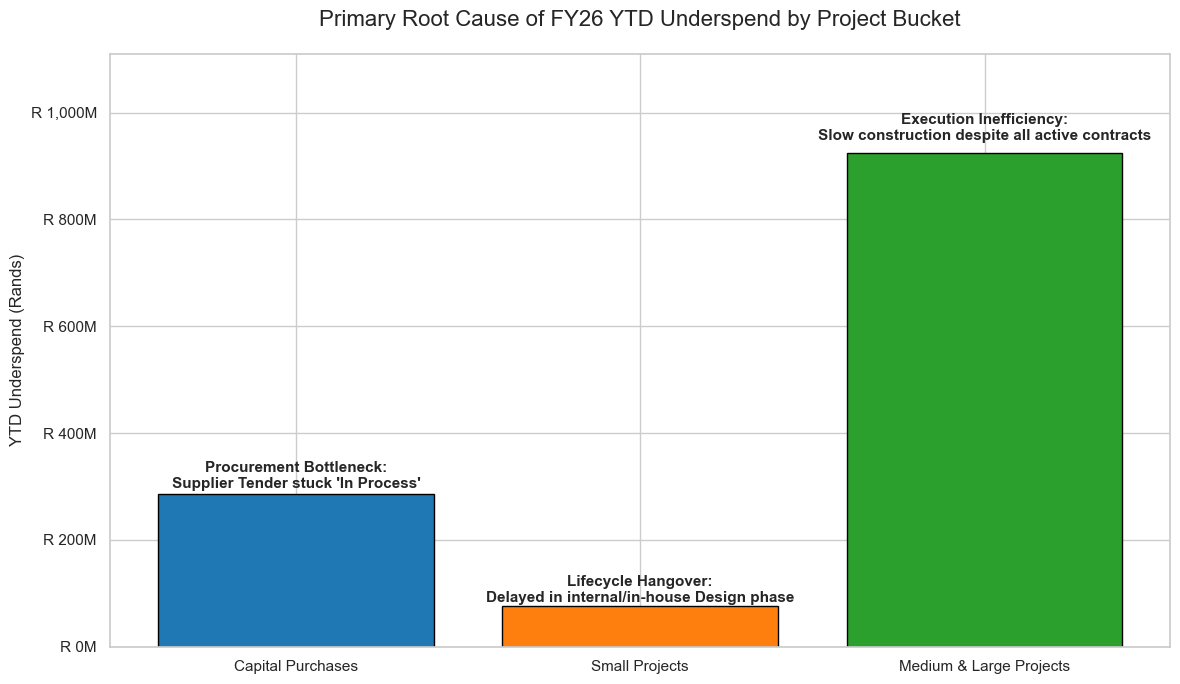

In [228]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def answer_q2_drilldown(df_financial, df_attributes, df_procurement):
 
    
    # 1. Calculate YTD Underspend (FY26, P1-P3)
    fy26_ytd = df_financial[(df_financial['Financial Year'] == 2026) & (df_financial['Period'] <= 3)]
    ytd_pivot = fy26_ytd.pivot_table(index='Project Item Identifier', columns='Financial View', values='Value', aggfunc='sum').reset_index().fillna(0)
    
    if 'Original Approved Budget' not in ytd_pivot.columns: ytd_pivot['Original Approved Budget'] = 0
    if 'Actual' not in ytd_pivot.columns: ytd_pivot['Actual'] = 0
    
    ytd_pivot['YTD_Underspend'] = ytd_pivot['Original Approved Budget'] - ytd_pivot['Actual']
    df_under = ytd_pivot[ytd_pivot['YTD_Underspend'] > 0].copy()
    
    # 2. Merge with attributes and map to required buckets (Medium & Large combined)
    df_merged = df_under.merge(df_attributes[['Project Item Identifier', 'Type', 'Stage']], on='Project Item Identifier', how='left')
    df_merged['Type_Lower'] = df_merged['Type'].astype(str).str.lower()
    
    def map_bucket(row):
        t = row['Type_Lower']
        if t == 'capital purchase': return 'Capital Purchases'
        elif t == 'small': return 'Small Projects'
        elif t in ['medium', 'large']: return 'Medium & Large Projects'
        else: return 'Other'
        
    df_merged['Project_Bucket'] = df_merged.apply(map_bucket, axis=1)
    
    # 3. Analyze highly specific Procurement Status per project
    df_proc = df_procurement.copy()
    df_proc['Status'] = df_proc['Status'].str.lower().str.strip()
    df_proc['Category'] = df_proc['Category'].str.lower().str.strip()
    
    proc_status = {}
    for proj_id, group in df_proc.groupby('Project Item Identifier'):
        cats = group['Category'].tolist()
        statuses = group['Status'].tolist()
        proj_dict = {'service': [], 'contractor': [], 'supplier': []}
        for c, s in zip(cats, statuses):
            if c in proj_dict:
                proj_dict[c].append(s)
        proc_status[proj_id] = proj_dict
        
    # 4. Determine root causes based on distinct project type rules
    def get_root_cause(row):
        proj_id = row['Project Item Identifier']
        bucket = row['Project_Bucket']
        stage = str(row['Stage']).lower()
        p_status = proc_status.get(proj_id, {'service': [], 'contractor': [], 'supplier': []})
        
        has_awarded_supplier = 'awarded' in p_status['supplier']
        has_awarded_contractor = 'awarded' in p_status['contractor']
        has_awarded_service = 'awarded' in p_status['service']
        
        if bucket == 'Capital Purchases':
            if not has_awarded_supplier:
                if 'in process' in p_status['supplier']: return "Procurement Bottleneck: Supplier Tender stuck 'In Process'"
                elif 'cancelled' in p_status['supplier']: return "Procurement Failure: Supplier Tender 'Cancelled'"
                else: return "Blocked: Missing Supplier Tender entirely"
            else:
                return "Execution Inefficiency: Slow delivery despite awarded Supplier"
                
        elif bucket == 'Small Projects':
            if stage == 'design':
                return "Lifecycle Hangover: Delayed in internal/in-house Design phase"
            elif not has_awarded_contractor:
                if 'in process' in p_status['contractor']: return "Procurement Bottleneck: Contractor Tender stuck 'In Process'"
                else: return "Blocked: Missing Contractor Tender entirely"
            else:
                return "Execution Inefficiency: Slow construction despite active Contractor"
                
        elif bucket == 'Medium & Large Projects':
            if not has_awarded_service:
                if 'in process' in p_status['service']: return "Procurement Bottleneck: PSP (Service) Tender stuck 'In Process'"
                else: return "Blocked early phase: Missing PSP (Service) Tender"
            elif stage == 'design':
                return "Lifecycle Hangover: Stuck in Design phase (inherent slow burn rate)"
            elif not has_awarded_contractor:
                if 'in process' in p_status['contractor']: return "Procurement Bottleneck: Contractor Tender stuck 'In Process'"
                else: return "Blocked execution: Missing Contractor Tender entirely"
            else:
                return "Execution Inefficiency: Slow construction despite all active contracts"
                
        return "Other"
        
    df_merged['Root_Cause'] = df_merged.apply(get_root_cause, axis=1)
    
    # 5. Extract and print the single highest financial driver per bucket
    buckets = ['Capital Purchases', 'Small Projects', 'Medium & Large Projects']
    plot_data = []
    
    print(f"Total Portfolio YTD Underspend Analysed: R {df_merged['YTD_Underspend'].sum():,.2f}\n")
    
    for b in buckets:
        b_data = df_merged[df_merged['Project_Bucket'] == b]
        if b_data.empty: continue
        
        total_b_underspend = b_data['YTD_Underspend'].sum()
        cause_agg = b_data.groupby('Root_Cause')['YTD_Underspend'].sum().sort_values(ascending=False)
        
        top_cause = cause_agg.index[0]
        top_cause_val = cause_agg.iloc[0]
        pct_of_bucket = (top_cause_val / total_b_underspend) * 100
        
        plot_data.append({'Bucket': b, 'Top Reason': top_cause, 'Underspend': top_cause_val})
        
        print(f"► {b.upper()}")
        print(f"  Total Underspend in Bucket: R {total_b_underspend:,.2f}")
        print(f"  Primary Root Cause: {top_cause}")
        print(f"  Financial Impact: R {top_cause_val:,.2f} ({pct_of_bucket:.1f}% of {b} underspend)\n")

    # 6. Visualize the definitive answer
    if plot_data:
        plot_df = pd.DataFrame(plot_data)
        fig, ax = plt.subplots(figsize=(12, 7))
        bars = ax.bar(plot_df['Bucket'], plot_df['Underspend'], color=['#1f77b4', '#ff7f0e', '#2ca02c'], edgecolor='black')
        
        ax.set_title("Primary Root Cause of FY26 YTD Underspend by Project Bucket", fontsize=16, pad=20)
        ax.set_ylabel("YTD Underspend (Rands)", fontsize=12)
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'R {x / 1e6:,.0f}M'))
        
        # Add labels on top of bars
        for bar, reason in zip(bars, plot_df['Top Reason']):
            yval = bar.get_height()
            # Split long text for better readability
            formatted_reason = reason.replace(': ', ':\n')
            ax.text(bar.get_x() + bar.get_width()/2, yval + (yval*0.02), formatted_reason, 
                    ha='center', va='bottom', fontsize=11, fontweight='bold')
            
        # Adjust y-limit to fit the text
        ax.set_ylim(0, plot_df['Underspend'].max() * 1.2)
        plt.tight_layout()
        plt.show()

# Run the drilldown
answer_q2_drilldown(df_financial, df_attributes, df_procurement)

## Attempt to understand the sudden drop betweeen FY25 and FY26

   EMPIRICAL INVESTIGATION: LIFECYCLE STAGE SHIFT



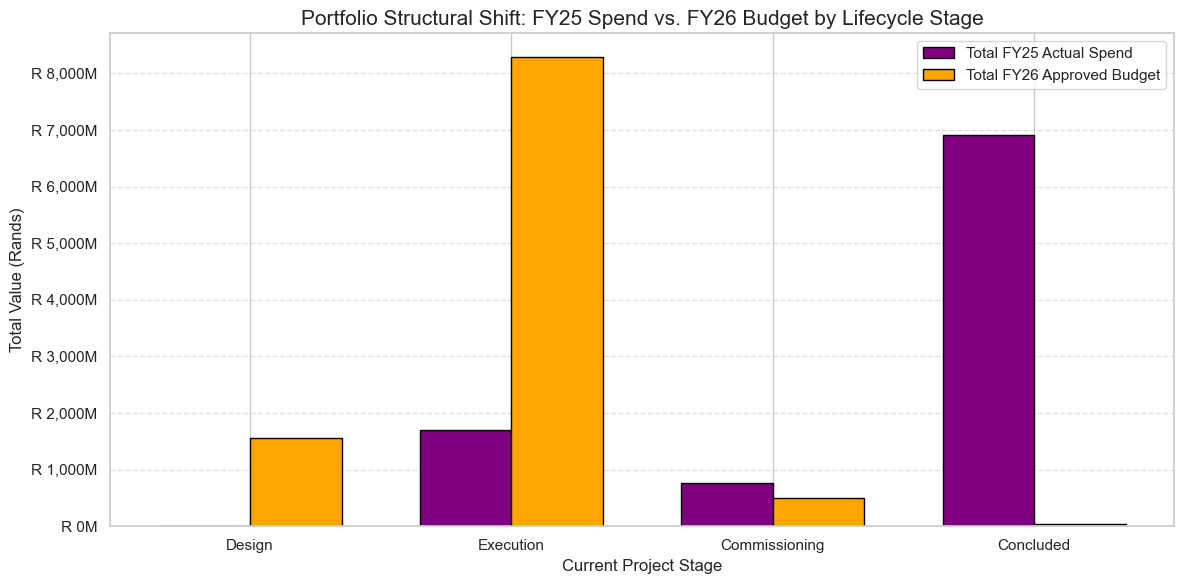

► EMPIRICAL FINDING: The Lifecycle Transition Gap
- Design: Drove 0.0% of FY25 Spend  -->  Holds 14.9% of FY26 Budget
- Execution: Drove 18.1% of FY25 Spend  -->  Holds 79.9% of FY26 Budget
- Commissioning: Drove 8.2% of FY25 Spend  -->  Holds 4.9% of FY26 Budget
- Concluded: Drove 73.7% of FY25 Spend  -->  Holds 0.3% of FY26 Budget

CONCLUSION:
Your hypothesis is correct. A massive 81.9% of all money spent in FY25 was driven by projects that are now 'Concluded' or in 'Commissioning'.
Meanwhile, 14.9% of the new FY26 budget is heavily tied up in projects that are currently stuck in 'Design' or 'Initiation'.
Because projects in early stages spend money exponentially slower than projects in Execution, the portfolio is experiencing a 'Lifecycle Hangover', causing the massive drop in expenditure at the start of FY26.


In [229]:
if notebook_analysis:
    analysis.investigate_lifecycle_shift(df_financial, df_attributes)


# Effects due to lifecycle stages

   EXPENDITURE BY LIFECYCLE STAGE ANALYSIS

--- Monthly Spend Statistics per Active Stage (Recent 2 Years) ---


,Average_Monthly_Spend,Median_Monthly_Spend,Max_Monthly_Spike,Months_with_Spend
Stage,,,,
Design,"R 2,325,097.78","R 2,317,376.64","R 8,945,678.00",50
Execution,"R 9,094,728.60","R 5,997,966.21","R 73,970,435.34",355
Commissioning,"R 7,659,037.35","R 4,014,914.48","R 37,292,882.31",164



Conclusion: The average monthly spend during Execution is 3.9x higher than during Design.


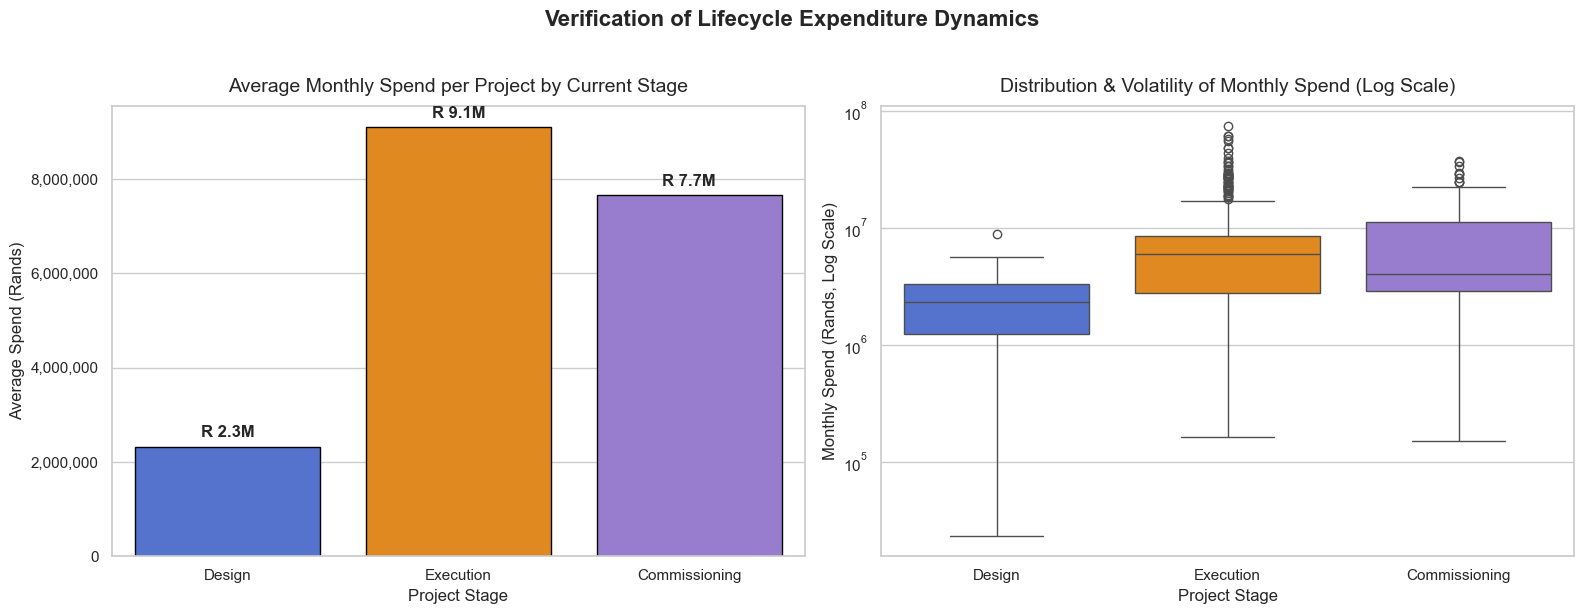

In [230]:
if notebook_analysis:
    analysis.analyze_expenditure_by_stage(df_fin_pivot, df_attributes)
